In [5]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\R Jyothi Prasanna\Desktop\PROJECT-1\WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.dropna(inplace=True)

df.drop(columns=["customerID"], inplace=True)

df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

df = pd.get_dummies(df, drop_first=True)

print(df.shape)

(7032, 31)


In [6]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5625, 30)
(1407, 30)


In [8]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [9]:
pred_lr = lr.predict(X_test)

print(pred_lr[:10])

[0 1 0 0 0 0 0 0 1 0]


In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred_lr)

print("Accuracy:", accuracy)

Accuracy: 0.8045486851457001


In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.58      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
print("Random Forest trained successfully!")

Random Forest trained successfully!


In [13]:
pred_rf = rf.predict(X_test)

In [14]:
print(pred_rf[:10])

[0 1 0 0 0 0 0 0 1 0]


In [15]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7896233120113717


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [17]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                           Feature  Importance
3                     TotalCharges    0.191435
1                           tenure    0.171020
2                   MonthlyCharges    0.168400
10     InternetService_Fiber optic    0.039481
28  PaymentMethod_Electronic check    0.037416
25               Contract_Two year    0.030529
4                      gender_Male    0.029332
13              OnlineSecurity_Yes    0.028157
26            PaperlessBilling_Yes    0.025536
19                 TechSupport_Yes    0.024114


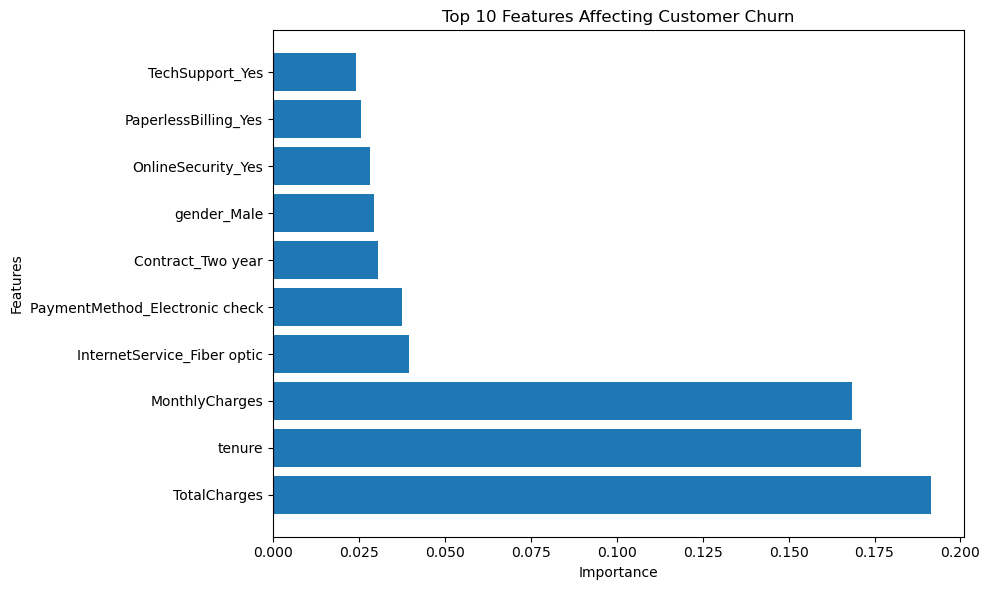

In [18]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Features Affecting Customer Churn")

plt.tight_layout()
plt.show()

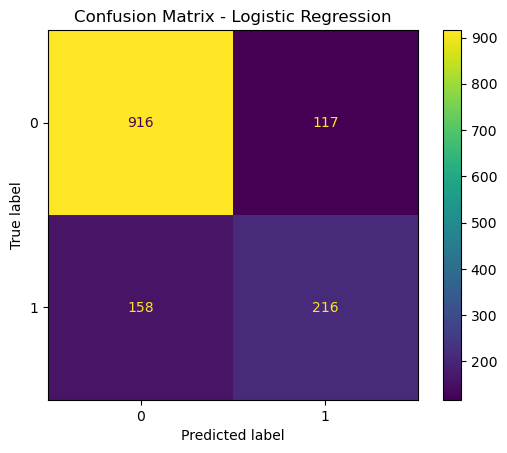

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    lr,
    X_test,
    y_test
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

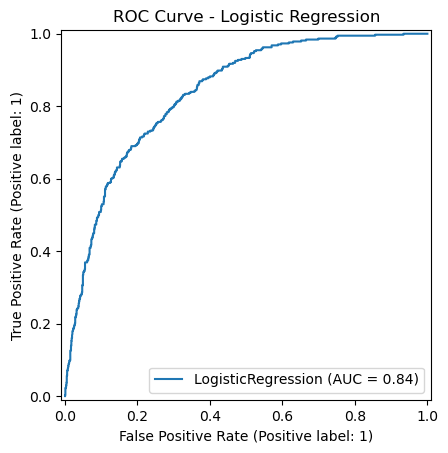

In [20]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(
    lr,
    X_test,
    y_test
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

In [21]:
import xgboost

print(xgboost.__version__)

3.2.0


In [22]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [23]:
pred_xgb = xgb.predict(X_test)

print(pred_xgb[:10])

[0 1 0 0 0 0 0 0 1 0]


In [24]:
from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(y_test, pred_xgb)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.7917555081734187


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



In [26]:
import joblib

joblib.dump(lr, "churn_model.pkl")

print("Model saved!")

Model saved!


In [27]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Feature names saved!")

Feature names saved!


In [28]:
import os

print(os.listdir())

['.anaconda', '.angular-config.json', '.appletviewer', '.conda', '.condarc', '.continuum', '.copilot', '.ghcp-appmod', '.ghcp-appmod-java', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.lesshst', '.local', '.matplotlib', '.spyder-py3', '.streamlit', '.vscode', '.vscode-shared', 'Anaconda3', 'anaconda_projects', 'app.py', 'AppData', 'Application Data', 'churn_model.pkl', 'Contacts', 'Cookies', 'csvfile.py', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'feature_columns.pkl', 'Jedi', 'Links', 'Loan Prediction Dataset.csv', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'node_modules', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{68b24691-b236-11ef-9682-f84ee16551d5}.TxR.0.regtrans-ms', 'NTUSER.DAT{68b24691-b236-11ef-9682-f84ee16551d5}.TxR.1.regtrans-ms', 'NTUSER.DAT{68b24691-b236-11ef-9682-f84ee16551d5}.TxR.2.regtrans-ms', 'NTUSER.DAT{68b24691-b236-11ef-9682-f84ee16551d5}.TxR.blf', 'NTUSER.DAT{68b24692-b236-11ef-9682-f84ee16551d5}.

In [29]:
import joblib

features = joblib.load("feature_columns.pkl")

for f in features:
    print(f)

SeniorCitizen
tenure
MonthlyCharges
TotalCharges
gender_Male
Partner_Yes
Dependents_Yes
PhoneService_Yes
MultipleLines_No phone service
MultipleLines_Yes
InternetService_Fiber optic
InternetService_No
OnlineSecurity_No internet service
OnlineSecurity_Yes
OnlineBackup_No internet service
OnlineBackup_Yes
DeviceProtection_No internet service
DeviceProtection_Yes
TechSupport_No internet service
TechSupport_Yes
StreamingTV_No internet service
StreamingTV_Yes
StreamingMovies_No internet service
StreamingMovies_Yes
Contract_One year
Contract_Two year
PaperlessBilling_Yes
PaymentMethod_Credit card (automatic)
PaymentMethod_Electronic check
PaymentMethod_Mailed check


In [30]:
# Find customers predicted as churn in the test set
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred_lr
})

print(results[results["Predicted"] == 1].head())

      Actual  Predicted
619        0          1
1346       1          1
4283       0          1
6128       0          1
346        1          1


In [31]:
idx = X_test[pred_lr == 1].index[0]

print(X_test.loc[idx])

SeniorCitizen                                 0
tenure                                        7
MonthlyCharges                            78.55
TotalCharges                             522.95
gender_Male                               False
Partner_Yes                               False
Dependents_Yes                            False
PhoneService_Yes                           True
MultipleLines_No phone service            False
MultipleLines_Yes                          True
InternetService_Fiber optic                True
InternetService_No                        False
OnlineSecurity_No internet service        False
OnlineSecurity_Yes                        False
OnlineBackup_No internet service          False
OnlineBackup_Yes                           True
DeviceProtection_No internet service      False
DeviceProtection_Yes                      False
TechSupport_No internet service           False
TechSupport_Yes                           False
StreamingTV_No internet service         